In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from astropy.io import fits

In [2]:
# Define the path to the simulation data
sim_path = '/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/z0/0G/simulation_z0_0G_14400s_28800s.nc'

data = nc.Dataset(sim_path)

dx_Mm = (data.variables['xc1'][:][1] - data.variables['xc1'][:][0]) / 1e8
dt_seconds = data.variables['time'][:][1] - data.variables['time'][:][0]

# Read the cube dimensions and keep the smaller horizontal extent for radial averaging.
nx = data.variables['xc1'][:].size
ny = data.variables['xc2'][:].size
nt = data.variables['time'][:].size

end_time = nt
end_space = min(nx, ny)
mid_time = end_time // 2
mid_space = end_space // 2
positive_frequency_count = end_time - mid_time

# Compute the Nyquist scales in wavenumber and temporal frequency.
k_nyquist = np.pi/float(dx_Mm)
nu_nyquist = (np.pi/float(dt_seconds))/(2.0*np.pi)*1.0e3

# Reconstruct the positive axes used by the notebook products.
k_axis = np.linspace(0.0, k_nyquist, mid_space, endpoint = True, dtype = np.float64)
nu_axis = np.linspace(0.0, nu_nyquist, positive_frequency_count, endpoint = True, dtype = np.float64)

# Import the functions of plots.ipynb to use in this notebook.
%run plots.ipynb

# Use the below function to load in the data at the following path
path = '/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Data/Time-Distance/z0_0g_v3_880km_1100km_gaussian_filtered_gauss_ck_1_wk_1_cf_3_wf_3_phase_diff.fits'

data = load_time_distance_data(path, 30, 0.16, axis_type = 'frequency', plot_cache = None)
freq_axis = data['vertical_axis']
radii_axis = data['radii']
phase_diff = data['values']*180/np.pi

# Make a meshgrid of the frequency and radii axes for plotting.
freq_mesh, radii_mesh = np.meshgrid(freq_axis, radii_axis)

# Plot the phase difference as a function of frequency and radii.
plt.figure(figsize=(10, 6))
plt.pcolormesh(radii_mesh, freq_mesh, phase_diff, shading='auto', cmap='viridis')
plt.colorbar(label='Phase Difference (radians)')
plt.title('Phase Difference as a Function of Frequency and Radii')
plt.ylabel('Frequency (mHz)')
plt.xlabel('Radii (Mm)')
plt.ylim(-5, 5)  # Limit the y-axis to the range of interest
plt.xlim(0, 10)   # Limit the x-axis to the range of interest
plt.show()

/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/Time-Distance/config.py
Running time_distance


FileNotFoundError: [Errno 2] No such file or directory: '/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Data/Time-Distance/filter_1/simulations/nonmagneto/0G/xcorr/annulus/v3/z0_0g_v3_440km_880km_xc.fits'

FileNotFoundError: [Errno 2] No such file or directory: '/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Data/Time-Distance/filter_1/simulations/nonmagneto/0G/xcorr/annulus/v3/z0_0g_v3_440km_880km_xc.fits'

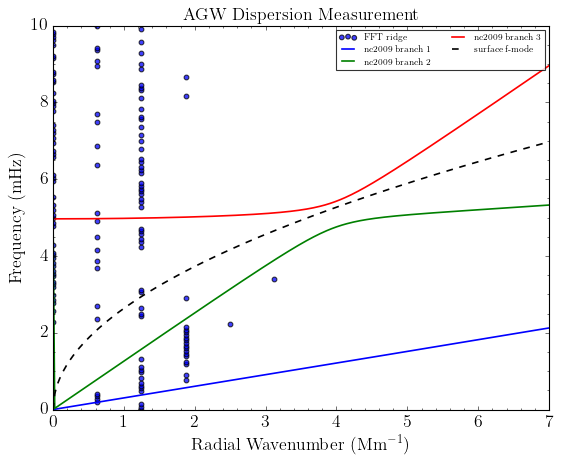

In [ ]:
from pathlib import Path
import copy
import importlib.util

# Choose which theory curves to overlay. Use ['all'] or any subset of:
# ['sf1966', 'mt1981', 'mt1982', 'bunte1993', 'nc2009'].
dispersion_models = ['nc2009']
include_fmode = True

plot_k_limits = (0, 7)
plot_nu_limits = (0, 10)
model_k = np.linspace(plot_k_limits[0], plot_k_limits[1], 300)
model_nu = np.linspace(plot_nu_limits[0], plot_nu_limits[1], 500)

project_dir = Path('/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a')
theory_dir = project_dir / 'Code' / 'Theory'

def load_module(module_name, module_path):
    spec = importlib.util.spec_from_file_location(module_name, module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

theory_functions = load_module('theory_functions', theory_dir / 'functions.py')
theory_config = load_module('theory_config', theory_dir / 'config.py')
DiagnosticDiagram = theory_functions.DiagnosticDiagram

available_models = list(theory_config.params.keys())
if isinstance(dispersion_models, str):
    dispersion_models = [dispersion_models]

requested_models = [str(model).strip().lower() for model in dispersion_models]
if 'all' in requested_models:
    requested_models = available_models

unknown_models = sorted(set(requested_models) - set(available_models))
if unknown_models:
    raise ValueError(f'Unknown dispersion model(s): {unknown_models}. Choose from {available_models}.')

# phase_diff is assumed to have shape [n_radii, n_freq].
phase_diff = data['values'] * 180 / np.pi
r = np.asarray(radii_axis, dtype=float)
dr = np.mean(np.diff(r))
if dr == 0:
    raise ValueError('radii axis spacing is zero')

n = phase_diff.shape[0]
k_cycles = np.fft.fftshift(np.fft.fftfreq(n, d=dr))
k_radial = 2 * np.pi * k_cycles
kh = np.zeros(phase_diff.shape[1])

for freq_index in range(phase_diff.shape[1]):
    phase_diff_cut = phase_diff[:, freq_index]
    fft = np.fft.fftshift(np.fft.fft(phase_diff_cut))
    power_spectrum = np.abs(fft) ** 2
    kh[freq_index] = abs(k_radial[np.argmax(power_spectrum)])

def plot_dispersion_model(ax, model_name, k_axis_Mm, nu_axis_mHz):
    params = copy.deepcopy(theory_config.params[model_name])
    params['model'] = model_name

    kh_grid_km = np.asarray(k_axis_Mm, dtype=float) / 1000.0
    omega_grid = np.asarray(nu_axis_mHz, dtype=float) * 1.0e-3 * 2.0 * np.pi
    diagram = DiagnosticDiagram(kh_grid_km, omega_grid, params)

    omega_roots = np.vstack([diagram.omega_solve(float(k_value)) for k_value in kh_grid_km])
    nu_roots = omega_roots / (2.0 * np.pi) * 1.0e3
    nu_roots = np.where(nu_roots > 0.0, nu_roots, np.nan)

    for branch_index in range(nu_roots.shape[1]):
        branch = nu_roots[:, branch_index]
        if np.count_nonzero(np.isfinite(branch)) < 2:
            continue
        ax.plot(k_axis_Mm, branch, linewidth=1.5, label=f'{model_name} branch {branch_index + 1}')

    return diagram

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(kh, freq_axis, s=18, alpha=0.75, label='FFT ridge')

first_diagram = None
for model_name in requested_models:
    diagram = plot_dispersion_model(ax, model_name, model_k, model_nu)
    if first_diagram is None:
        first_diagram = diagram

if include_fmode and first_diagram is not None:
    fmode_nu = first_diagram.fmode_dispersion() / (2.0 * np.pi) * 1.0e3
    ax.plot(model_k, fmode_nu, color='black', linestyle='--', linewidth=1.5, label='surface f-mode')

ax.set_title('AGW Dispersion Measurement')
ax.set_xlabel(r'Radial Wavenumber ($\mathrm{Mm}^{-1}$)')
ax.set_ylabel('Frequency (mHz)')
ax.set_ylim(*plot_nu_limits)
ax.set_xlim(*plot_k_limits)
ax.legend(fontsize=8, ncols=2)
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

path = '/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Data/Time-Distance/z0_0g_v3_880km_1100km_gaussian_filtered_gauss_ck_1_wk_1_cf_3_wf_3_xc.fits'

# Load in the data
f = load_time_distance_data(path, 30, 0.16, axis_type='time_lag', plot_cache=None)
data = np.rot90(fits.getdata(path))

# Normalize each column of the data to the range [-1, 1]
data = 2 * (data - np.min(data, axis=0)) / (np.max(data, axis=0) - np.min(data, axis=0)) - 1

freq_axis = f['vertical_axis']

v_kms = 4.2  # km/s
v_Mm_per_min = v_kms * 60 / 1000
y = (1 / v_Mm_per_min) * radii_axis

# Store (tau_r, freq) pairs here
tau_r_points = []

for freq_index, freq in enumerate(freq_axis):
    # 1D slice at the i-th frequency index
    phase_diff_slice = phase_diff[:, freq_index]

    # Optional smoothing for noisy sinusoidal data
    phase_diff_smooth = savgol_filter(
        phase_diff_slice,
        window_length=9,   # must be odd
        polyorder=3
    )

    maxima_indices, properties = find_peaks(
        phase_diff_smooth,
        prominence=100,
        distance=5
    )

    # Skip frequencies with no detected peaks
    if len(maxima_indices) == 0:
        continue

    maxima_values = phase_diff_slice[maxima_indices]

    # Target amplitude = max / e
    target_value = np.max(np.abs(phase_diff_slice)) / np.e

    # Find the peak closest to the target amplitude
    closest_index = np.argmin(np.abs(np.abs(maxima_values) - target_value))

    # Radius at that peak
    radii_at_target = radii_axis[maxima_indices[closest_index]]

    # Radiative damping timescale in seconds
    tau_r = radii_at_target * 1e3 / v_kms

    # Store the coordinates
    tau_r_points.append((tau_r, freq))

tau_r_points = np.array(tau_r_points)

# If you want separate arrays:
tau_r_values = tau_r_points[:, 0]
freq_values = tau_r_points[:, 1]

# Plot the line on top of the data
plt.figure(figsize=(6, 7))
plt.imshow(
    data,
    aspect='auto',
    cmap='viridis',
    extent=[np.min(radii_axis), np.max(radii_axis), np.min(freq_axis), np.max(freq_axis)]
)
plt.ylim(-60, 60)
plt.plot(radii_axis, y, color='red', label=f'v = {v_kms} km/s')
plt.colorbar(label='Normalized Cross-Correlation')
plt.title('Cross-Correlation Data with Slope Line')
plt.xlabel('Radii (Mm)')
plt.ylabel('Time-Lag (min)')
plt.show()

# Plot the extracted (tau_r, freq) points
plt.figure(figsize=(6, 7))
plt.plot(freq_values, tau_r_values, color='blue', label='Extracted Points')
plt.xlim(0, 5)  # Limit the y-axis to the range of interest
plt.ylabel('Radiative Damping Timescale (s)')
plt.xlabel('Frequency (mHz)')
plt.title('Extracted (tau_r, freq) Points')
plt.legend()
plt.show()